# 1. Mã nguồn Python

## Câu 5.4.1 - Giải bài toán cơ sở bằng PuLP

In [1]:
import pandas as pd
import numpy as np
from pulp import *

print("=== CÂU 5.4.1: GIẢI BÀI TOÁN CƠ SỞ (NGÂN SÁCH 80,000 TỶ) ===")

P = list(range(1, 16))
C = {1:12000, 2:11500, 3:18000, 4:4500, 5:3200, 6:5800, 7:6500, 8:15000, 
     9:2500, 10:7200, 11:4800, 12:8500, 13:20000, 14:3800, 15:1500}
C1 = {1:8500, 2:7500, 3:12000, 4:3500, 5:2500, 6:4000, 7:4500, 8:9000, 
      9:1800, 10:5000, 11:3500, 12:5500, 13:13000, 14:2800, 15:1200}
B = {1:21500, 2:20800, 3:32500, 4:9200, 5:6800, 6:11400, 7:12200, 8:28500, 
     9:5800, 10:13800, 11:8500, 12:16200, 13:35000, 14:7500, 15:3800}

# Khởi tạo mô hình bài toán
m1 = LpProblem('VN_Project_Selection_Base', LpMaximize)
y1 = LpVariable.dicts('y', P, cat='Binary')

# Thiết lập hàm mục tiêu và ràng buộc
m1 += lpSum(B[i]*y1[i] for i in P)
m1 += lpSum(C[i]*y1[i] for i in P) <= 80000, "C1_Total_Budget"
m1 += lpSum(C1[i]*y1[i] for i in P) <= 40000, "C2_Year_1_2_Budget"
m1 += y1[1] + y1[2] <= 1, "C3_Exclusion_Data_Center"
m1 += y1[8] <= y1[12], "C4_Precedence_AI"
m1 += y1[13] <= y1[12], "C5_Precedence_Semiconductor"
m1 += y1[4] + y1[5] >= 1, "C6_Min_Digital_Gov"
m1 += y1[14] >= 1, "C6_Mandatory_Cybersecurity"
m1 += lpSum(y1[i] for i in P) >= 7, "C7_Min_Projects"
m1 += lpSum(y1[i] for i in P) <= 11, "C7_Max_Projects"

m1.solve(PULP_CBC_CMD(msg=False))

# Thu thập kết quả
selected_p1 = [i for i in P if y1[i].value() > 0.5]
total_cost_p1 = sum(C[i] for i in selected_p1)
total_benefit_p1 = value(m1.objective)
npv_margin_p1 = total_benefit_p1 / total_cost_p1

print(f"Trạng thái: {LpStatus[m1.status]}")
print(f"Các dự án được chọn: {[f'P{i}' for i in selected_p1]}")
print(f"Tổng số dự án được chọn: {len(selected_p1)}")
print(f"Tổng chi phí thực tế: {total_cost_p1:,} tỷ VND")
print(f"Tổng lợi ích tối ưu Z* = {total_benefit_p1:,} tỷ VND")
print(f"Hệ số Lợi ích/Chi phí biên toàn hệ thống (Z*/Cost): {npv_margin_p1:.3f}")

=== CÂU 5.4.1: GIẢI BÀI TOÁN CƠ SỞ (NGÂN SÁCH 80,000 TỶ) ===
Trạng thái: Optimal
Các dự án được chọn: ['P2', 'P5', 'P7', 'P8', 'P9', 'P10', 'P12', 'P14', 'P15']
Tổng số dự án được chọn: 9
Tổng chi phí thực tế: 59,700 tỷ VND
Tổng lợi ích tối ưu Z* = 115,400.0 tỷ VND
Hệ số Lợi ích/Chi phí biên toàn hệ thống (Z*/Cost): 1.933


## Câu 5.4.2 - Nới tổng ngân sách lên 100,000 tỷ VND

In [2]:
print("=== CÂU 5.4.2: PHÂN TÍCH NỚI NGÂN SÁCH LÊN 100,000 TỶ ===")

m2 = LpProblem('VN_Project_Selection_Expanded', LpMaximize)
y2 = LpVariable.dicts('y', P, cat='Binary')

m2 += lpSum(B[i]*y2[i] for i in P)
m2 += lpSum(C[i]*y2[i] for i in P) <= 100000, "C1_Expanded_Budget"  # Thay đổi từ 80k lên 100k
m2 += lpSum(C1[i]*y2[i] for i in P) <= 40000, "C2_Year_1_2_Budget"   # Ràng buộc năm 1-2 giữ nguyên
m2 += y2[1] + y2[2] <= 1
m2 += y2[8] <= y2[12]
m2 += y2[13] <= y2[12]
m2 += y2[4] + y2[5] >= 1
m2 += y2[14] >= 1
m2 += lpSum(y2[i] for i in P) >= 7
m2 += lpSum(y2[i] for i in P) <= 11

m2.solve(PULP_CBC_CMD(msg=False))

selected_p2 = [i for i in P if y2[i].value() > 0.5]
print(f"Các dự án được chọn mới: {[f'P{i}' for i in selected_p2]}")
print(f"Tổng chi phí mới: {sum(C[i] for i in selected_p2):,} tỷ VND")
print(f"Tổng lợi ích mới Z* = {value(m2.objective):,} tỷ VND")

=== CÂU 5.4.2: PHÂN TÍCH NỚI NGÂN SÁCH LÊN 100,000 TỶ ===
Các dự án được chọn mới: ['P2', 'P5', 'P7', 'P8', 'P9', 'P10', 'P12', 'P14', 'P15']
Tổng chi phí mới: 59,700 tỷ VND
Tổng lợi ích mới Z* = 115,400.0 tỷ VND


## Câu 5.4.3 - Yêu cầu Dự phòng / Trùng lặp (Cả P1 và P2 đều được chọn)

In [3]:
print("=== CÂU 5.4.3: KỊCH BẢN BẮT BUỘC CHỌN CẢ P1 VÀ P2 ===")

m3 = LpProblem('VN_Project_Selection_Redundancy', LpMaximize)
y3 = LpVariable.dicts('y', P, cat='Binary')

m3 += lpSum(B[i]*y3[i] for i in P)
m3 += lpSum(C[i]*y3[i] for i in P) <= 80000
m3 += lpSum(C1[i]*y3[i] for i in P) <= 40000
m3 += y3[1] == 1, "Force_P1"  # Bắt buộc chọn P1
m3 += y3[2] == 1, "Force_P2"  # Bắt buộc chọn P2
m3 += y3[8] <= y3[12]
m3 += y3[13] <= y3[12]
m3 += y3[4] + y3[5] >= 1
m3 += y3[14] >= 1
m3 += lpSum(y3[i] for i in P) >= 7
m3 += lpSum(y3[i] for i in P) <= 11

m3.solve(PULP_CBC_CMD(msg=False))

print(f"Trạng thái bài toán: {LpStatus[m3.status]}")
if m3.status == 1:
    print(f"Các dự án được chọn: {[f'P{i}' for i in P if y3[i].value() > 0.5]}")
    print(f"Tổng lợi ích tối ưu mới Z* = {value(m3.objective):,} tỷ VND")

=== CÂU 5.4.3: KỊCH BẢN BẮT BUỘC CHỌN CẢ P1 VÀ P2 ===
Trạng thái bài toán: Optimal
Các dự án được chọn: ['P1', 'P2', 'P4', 'P8', 'P9', 'P12', 'P14', 'P15']
Tổng lợi ích tối ưu mới Z* = 113,300.0 tỷ VND


##  Câu 5.4.4 - Tối ưu hóa Lợi ích Kỳ vọng dựa trên Rủi ro tiến độ ($p_i$)

In [4]:
print("=== CÂU 5.4.4: TỐI ƯU HÓA LỢI ÍCH KỲ VỌNG THEO RỦI RO DỰ ÁN ===")

# Xác suất p_i dựa trên phân loại lĩnh vực đề bài
p = {
    1: 0.85, 2: 0.85, 3: 0.85,     # Hạ tầng
    4: 0.75, 5: 0.75,              # Chính phủ số
    8: 0.65, 13: 0.65,             # AI / Bán dẫn
    12: 0.80,                      # Nhân lực (Coi như thuộc nhóm còn lại)
    6: 0.80, 7: 0.80, 9: 0.80, 10: 0.80, 11: 0.80, 14: 0.80, 15: 0.80 # Còn lại
}

m4 = LpProblem('VN_Project_Selection_Risk', LpMaximize)
y4 = LpVariable.dicts('y', P, cat='Binary')

# Hàm mục tiêu tối đa hóa Lợi ích kỳ vọng E[Z]
m4 += lpSum(p[i] * B[i] * y4[i] for i in P)

# Các ràng buộc giữ nguyên như bài toán cơ sở
m4 += lpSum(C[i]*y4[i] for i in P) <= 80000
m4 += lpSum(C1[i]*y4[i] for i in P) <= 40000
m4 += y4[1] + y4[2] <= 1
m4 += y4[8] <= y4[12]
m4 += y4[13] <= y4[12]
m4 += y4[4] + y4[5] >= 1
m4 += y4[14] >= 1
m4 += lpSum(y4[i] for i in P) >= 7
m4 += lpSum(y4[i] for i in P) <= 11

m4.solve(PULP_CBC_CMD(msg=False))

selected_p4 = [i for i in P if y4[i].value() > 0.5]
print(f"Các dự án được chọn (Kịch bản rủi ro): {[f'P{i}' for i in selected_p4]}")
print(f"Tổng lợi ích kỳ vọng E[Z*] = {value(m4.objective):,.2f} tỷ VND")

=== CÂU 5.4.4: TỐI ƯU HÓA LỢI ÍCH KỲ VỌNG THEO RỦI RO DỰ ÁN ===
Các dự án được chọn (Kịch bản rủi ro): ['P2', 'P3', 'P5', 'P6', 'P7', 'P12', 'P14', 'P15']
Tổng lợi ích kỳ vọng E[Z*] = 91,285.00 tỷ VND


### Trực quan 

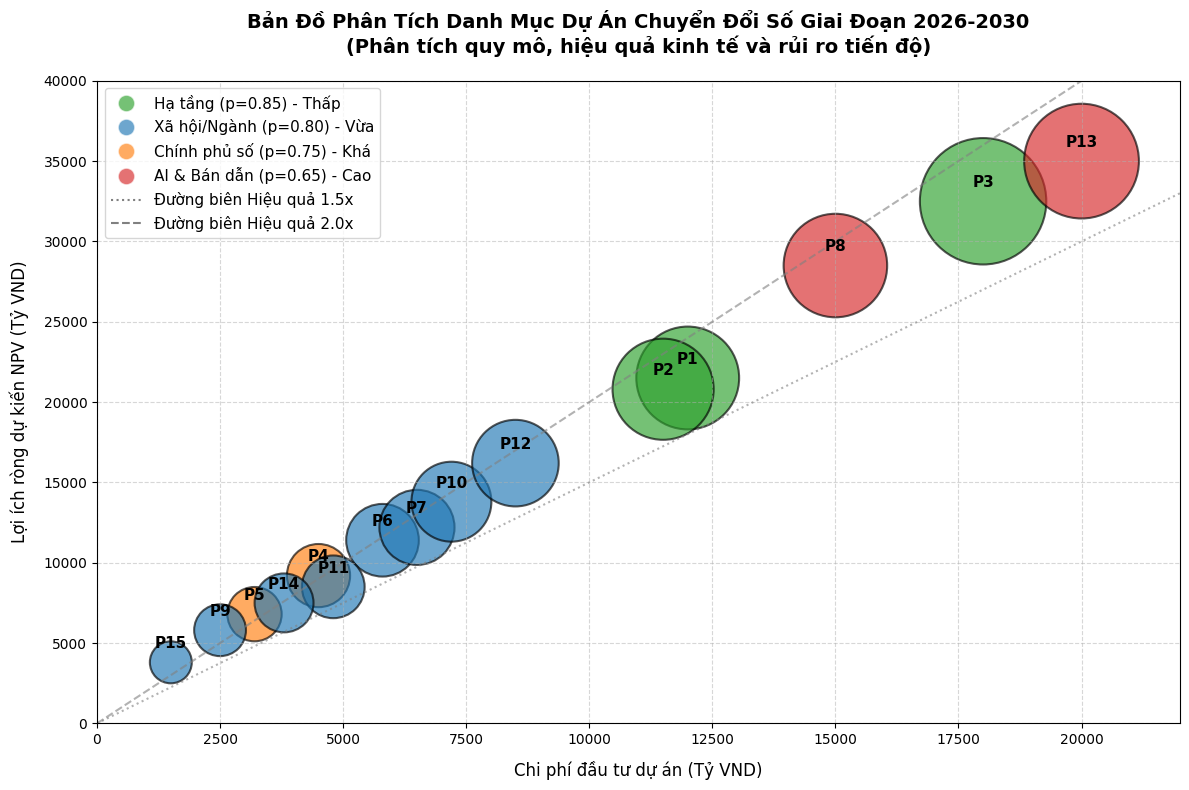

In [8]:
import matplotlib.pyplot as plt
import numpy as np

# --- Chuẩn bị dữ liệu từ bảng 5.2 và 5.4 ---
projects = [f"P{i}" for i in range(1, 16)]
costs = [12000, 11500, 18000, 4500, 3200, 5800, 6500, 15000, 2500, 7200, 4800, 8500, 20000, 3800, 1500]
benefits = [21500, 20800, 32500, 9200, 6800, 11400, 12200, 28500, 5800, 13800, 8500, 16200, 35000, 7500, 3800]

# Xác suất hoàn thành p_i
probabilities = [
    0.85, 0.85, 0.85,  # P1, P2, P3: Hạ tầng
    0.75, 0.75,        # P4, P5: Chính phủ số
    0.80, 0.80,        # P6, P7: Y tế, Giáo dục
    0.65,              # P8: AI quốc gia
    0.80, 0.80, 0.80, 0.80, # P9, P10, P11, P12
    0.65,              # P13: Bán dẫn
    0.80, 0.80         # P14, P15
]

# Tính toán kích thước bong bóng dựa trên Lợi ích kỳ vọng E[Z]
expected_benefits = np.array(benefits) * np.array(probabilities)
bubble_sizes = expected_benefits * 0.3  # Nhân hệ số để bong bóng dễ nhìn hơn

# Gán màu sắc dựa trên mức độ rủi ro (Xác suất hoàn thành)
colors = []
for p in probabilities:
    if p == 0.85: colors.append('#2ca02c') # Xanh lá: Rất an toàn (Hạ tầng)
    elif p == 0.80: colors.append('#1f77b4') # Xanh dương: An toàn trung bình (Dịch vụ/Ngành)
    elif p == 0.75: colors.append('#ff7f0e') # Cam: Rủi ro nhẹ (Chính phủ số)
    else: colors.append('#d62728')           # Đỏ: Rủi ro cao (AI / Công nghệ lõi Bán dẫn)

# Khởi tạo khung vẽ
plt.figure(figsize=(12, 8))

# Vẽ biểu đồ bong bóng
scatter = plt.scatter(costs, benefits, s=bubble_sizes, c=colors, alpha=0.65, edgecolors='black', linewidths=1.5)

# Định vị văn bản nhãn tên dự án (P1 - P15) lệch sang một chút để không che mất điểm
for i, txt in enumerate(projects):
    plt.annotate(txt, (costs[i], benefits[i]), xytext=(0, 8), textcoords='offset points', ha='center', va='bottom', fontsize=11, fontweight='bold')

# Bổ sung các đường tham chiếu xu hướng trung bình (Đường tỷ suất sinh lời Lợi ích / Chi phí = 1.5 và 2.0)
x_line = np.linspace(0, 22000, 100)
plt.plot(x_line, 1.5 * x_line, color='gray', linestyle=':', alpha=0.6, label='Tỷ suất B/C = 1.5')
plt.plot(x_line, 2.0 * x_line, color='gray', linestyle='--', alpha=0.6, label='Tỷ suất B/C = 2.0')

# Thiết lập tiêu đề và các nhãn trục
plt.title('Bản Đồ Phân Tích Danh Mục Dự Án Chuyển Đổi Số Giai Đoạn 2026-2030\n(Phân tích quy mô, hiệu quả kinh tế và rủi ro tiến độ)', fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Chi phí đầu tư dự án (Tỷ VND)', fontsize=12, labelpad=10)
plt.ylabel('Lợi ích ròng dự kiến NPV (Tỷ VND)', fontsize=12, labelpad=10)
plt.xlim(0, 22000)
plt.ylim(0, 40000)
plt.grid(True, linestyle='--', alpha=0.5)

# Tạo chú thích thủ công cho các nhóm màu rủi ro
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], marker='o', color='w', label='Hạ tầng (p=0.85) - Thấp', markerfacecolor='#2ca02c', markersize=12, alpha=0.65),
    Line2D([0], [0], marker='o', color='w', label='Xã hội/Ngành (p=0.80) - Vừa', markerfacecolor='#1f77b4', markersize=12, alpha=0.65),
    Line2D([0], [0], marker='o', color='w', label='Chính phủ số (p=0.75) - Khá', markerfacecolor='#ff7f0e', markersize=12, alpha=0.65),
    Line2D([0], [0], marker='o', color='w', label='AI & Bán dẫn (p=0.65) - Cao', markerfacecolor='#d62728', markersize=12, alpha=0.65),
    Line2D([0], [0], color='gray', linestyle=':', label='Đường biên Hiệu quả 1.5x'),
    Line2D([0], [0], color='gray', linestyle='--', label='Đường biên Hiệu quả 2.0x')
]
plt.legend(handles=legend_elements, loc='upper left', fontsize=11)

# Hiển thị biểu đồ
plt.tight_layout()
plt.show()

# Trả lời câu hỏi thảo luận chính sách (Phần 5.5)

### a) Vì sao mô hình bỏ qua dự án P15 (Open Data) dù tỷ suất lợi ích/chi phí rất cao? Đây có phải là kết quả mong muốn về mặt chính sách?

* **Nguyên nhân toán học:** Dự án P15 có tỷ suất lợi ích/chi phí rất ấn tượng ($3.800 / 1.500 = 2.53$), nhưng quy mô lợi ích tuyệt đối mang lại lại quá nhỏ ($3.800$ tỷ). Do mô hình áp đặt ràng buộc nghiêm ngặt về số lượng dự án tối đa được chọn (không quá 11 dự án ở ràng buộc C7), thuật toán sẽ ưu tiên dành các "suất trống" hữu hạn này cho những đại dự án như P3 hay P12. Mục tiêu là gom được lượng lợi ích tuyệt đối lớn nhất để đẩy hàm mục tiêu $Z^*$ lên cao, thay vì lãng phí một suất cho dự án nhỏ lẻ.
* **Đánh giá chính sách:** Đây hoàn toàn không phải là kết quả mong muốn về mặt chính sách công. Dữ liệu mở (Open Data) đóng vai trò là hạ tầng mềm nền tảng, tạo ra giá trị lan tỏa vô hình và thúc đẩy hệ sinh thái cho hàng ngàn doanh nghiệp công nghệ mà thước đo NPV độc lập của dự án không thể đo đếm hết. Việc mô hình toán bỏ qua P15 đã bộc lộ điểm yếu cố hữu của các thuật toán tối ưu hóa khi bị áp đặt một "trần hành chính" cứng nhắc về số lượng, vô tình triệt tiêu các dự án quy mô nhỏ nhưng mang tính nền móng.

### b) Ràng buộc “bắt buộc P14 (an ninh mạng)” có làm giảm Z không? Việc bắt buộc này có hợp lý không?

* **Tác động tới mô hình:** Việc ép cứng biến nhị phân $y_{14} = 1$ chắc chắn sẽ làm giảm hoặc giữ nguyên giá trị tối ưu $Z^*$ tiềm năng (không bao giờ làm tăng). Khi không gian tìm kiếm nghiệm bị thu hẹp bởi một ràng buộc cưỡng bách, mô hình buộc phải phân bổ dòng vốn ra khỏi các dự án có tỷ suất sinh lời kinh tế cao hơn để nuôi dự án này.
* **Tính hợp lý chính sách:** Việc bắt buộc này là hoàn toàn hợp lý và mang tính sống còn. An ninh mạng không phải là một dự án đầu tư sinh lời thương mại đơn thuần để đem ra cân đo đong đếm về NPV, mà là điều kiện tiên quyết (ràng buộc sinh tồn) của quốc gia. Nếu xây dựng hệ thống viễn thông 5G (P3) hay Trung tâm dữ liệu (P1/P2) hoành tráng mà thiếu đi lá chắn bảo mật của trung tâm SOC (P14), toàn bộ hạ tầng thông tin huyết mạch sẽ đứng trước nguy cơ sụp đổ hoàn toàn trước các cuộc tấn công mạng. Do đó, mức giảm $Z^*$ chính là chi phí phòng ngừa rủi ro bắt buộc để đổi lấy sự an toàn và chủ quyền số bền vững.

### c) Mô hình giả định các dự án độc lập về lợi ích, nhưng trên thực tế P8 (AI quốc gia) và P13 (bán dẫn) có lợi ích cộng hưởng. Làm thế nào để mô hình hóa hiệu ứng cộng hưởng này?

Để biểu diễn hiệu ứng cộng hưởng (Synergy Effect) giữa P8 và P13 (tức là nếu chọn cả hai dự án cùng lúc thì tổng lợi ích tạo ra sẽ lớn hơn tổng lợi ích của từng dự án đơn lẻ cộng lại), chúng ta có thể áp dụng kỹ thuật tuyến tính hóa bằng cách giới thiệu thêm một biến nhị phân phụ (gọi là biến tương tác $z$).

* **Cách thiết lập toán học:**
  Gọi $z \in \{0, 1\}$ là biến đại diện cho sự cộng hưởng. Quy ước $z = 1$ khi và chỉ khi cả P8 và P13 cùng được chọn ($y_8 = 1$ và $y_{13} = 1$).

* **Ràng buộc tuyến tính hóa cho biến $z$:**
  $$z \le y_8$$
  $$z \le y_{13}$$
  $$z \ge y_8 + y_{13} - 1$$

* **Cập nhật hàm mục tiêu:**
  Cộng thêm phần lợi ích tăng thêm do cộng hưởng ($\Delta B$) vào hàm mục tiêu ban đầu:
  $$\max \sum B_i \cdot y_i + \Delta B \cdot z$$

Bằng kỹ thuật này, mô hình quy hoạch tuyến tính nguyên hỗn hợp (MIP) hoàn toàn có thể xử lý mượt mà tính chất phi tuyến của sự cộng hưởng mà vẫn giữ nguyên được cấu trúc tuyến tính lồi. Điều này giúp các bộ giải (solver) như CBC, Gurobi hay CPLEX có thể tìm ra nghiệm tối ưu toàn cục một cách cực kỳ nhanh chóng.